# Assignment 2 - Numbers to Neurons

---
> Complete each question below. Write theory answers in Markdown cells and code in code cells.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

---
## Q1 - Perceptrons and Sigmoid Neurons

### Q1a - NAND Perceptron

Write a Python class using NumPy that implements a **NAND logic gate** using a single perceptron. Your implementation must use **vectorized operations** (no explicit `for` loops in the activation function) to process an input matrix of shape `(N, 2)` and return the corresponding binary outputs.

Mathematically determine and set the correct weights and bias within your code.

In [ ]:
#code here
weights = np.array([-2,-2])
bias = 3
class NAND:
    def __init__(self, weights, bias):
        self.weights = weights
        self.bias = bias

    def forward(self, x):
        z = np.dot(x, self.weights) + self.bias
        return (z >= 0).astype(int)

NAND_perceptron = NAND(weights, bias)


### Q1b - Perceptron Sensitivity

Explain precisely why a tiny change in one weight can cause **chaos** in a perceptron network. What property of the perceptron makes this happen?

> **Your answer:**

A perceptron gives follows a binary output scheme which states that output will be 1 if z>=0 and output will be 0 if z<0 where z = (w1x1 + w2x2 +.....) + b.

Now even a slight change can cause the entire output of the perceptron to flip which will affect other perceptrons that recieve the forward pass of this perceptron. This is because of the step-function output fasion that the perceptron follows.




---
## Q2 - The Quadratic Cost Function

$$C(w,b) = \frac{1}{2n} \sum_x \|y(x) - a\|^2$$

### Q2a - The Factor of 1/2

Why is there a factor of 1/2 in front? Derive why it is mathematically convenient when computing the derivative of C with respect to any weight w.

> **Your answer:**  
> Its just that when we first take a derivative wrt to a weight 'w' we first differentiate the inner term wrt y(x) which causes the power of 2 to come down and cancel out with the 1/2 term. This makes furthur calculations easier since the half term that would otherwise carry forward for backpropagation steps is now not there anymore.


### Q2b - Computing C by Hand

A network has two training examples:
- Example 1: output = 0.9, target = 1.0
- Example 2: output = 0.3, target = 0.0

Compute C by hand and explain what the value tells you about network performance.

> **Your answer:**\
> First the differences -> (0.9 - 1.0)$^2$ = $0.01$, (0.3 - 0.0)$^2$ = $0.09$  
> Sum of the differences squared = $0.1$  
> C = 1/(2*2) * 0.1 -> $C = 0.025$  
> **This means that the network is performing well since the cost is near 0**

In [ ]:
# Verify your hand computation
outputs = np.array([0.9, 0.3])
targets = np.array([1.0, 0.0])

difference = outputs-targets
difference = difference**2
C_val = np.sum(difference)/(2*2)
# TODO: compute C
print(f'C = {C_val}')

C = 0.024999999999999998


### Q2c - Cost vs Accuracy

Explain why we use a cost function and do **not** directly maximise classification accuracy.

> **Your answer:**\
> Accuracy is **not a function** and gives no idea on how to improve the network or what direction the changes need to be in. Creating a cost function gives us a differentiable function that tells us in which direction the weights and biases of the previous layer need to be tipped to imporove the network's result. This leads to furthur concepts such as **Gradient Decent** and **Back Propagation** that help change the weights and biases inturn minimizing the cost function and training the network.

### Q2d - Absolute Error vs Squared Error

An alternative cost is the absolute error: C = (1/n) * sum |y(x) - a|.

Explain **one mathematical problem** with using absolute error instead of squared error, specifically when doing gradient descent.

> **Your answer:**\
> Gradient descent minimizes the cost function using the gradient of the cost function. The squared error gives a gradient that decreases to zero as it approaches the minimum while the absolute error has a gradient = $+-C$ where C is a constant. Hence the absolute error as a cost function leaves the network oscillating around a minimum while a squared error function helps the step sizes get smaller leading to a more accurate result.

---
## Q3 - Gradient Descent on a Toy Cost Function

$$C(w, b) = (w - 3)^2 + 2(b - 1)^2$$

### Q3a - Minimum by Inspection

By inspection, what values of w and b minimise C? What is the minimum value of C? Explain your reasoning without calculus.

> **Your answer:**\
> Minimum will be reached when $$w=3, b=1$$\
> $$-> C(3,1) = 0$$\
> This is because both the terms are squared and will be >=0.

### Q3b - Two Steps by Hand

Compute dC/dw and dC/db. Starting from (w, b) = (0, 0) with learning rate eta = 0.1, show the first two gradient descent update steps by hand. Where does the parameter vector end up after step 2?

> **Your answer:**  
> dC/dw = 2(w-3) = -6  
> dC/db = 4(b-1)  = -4  
> --> (0.6,0.4)  
> dC/dw = -4.8  
> dC/db = -2.4  
> --> (1.08,0.64) (Final after 2 GD update steps)


In [ ]:
def cost(w, b):
    return (w - 3)**2 + 2*(b - 1)**2

def grad_cost(w, b):
    dw = 2*(w-3) # TODO
    db = 4*(b-1) # TODO
    return dw, db

# Verify your hand calculation
eta = 0.1
w, b = 0.0, 0.0
for step in range(1, 40):
    dw, db = grad_cost(w, b)
    w = w - eta * dw
    b = b - eta * db
    print(f'Step {step}: w={w:.4f}, b={b:.4f}, C={cost(w,b):.4f}')

Step 1: w=0.6000, b=0.4000, C=6.4800
Step 2: w=1.0800, b=0.6400, C=3.9456
Step 3: w=1.4640, b=0.7840, C=2.4526
Step 4: w=1.7712, b=0.8704, C=1.5435
Step 5: w=2.0170, b=0.9222, C=0.9785
Step 6: w=2.2136, b=0.9533, C=0.6228
Step 7: w=2.3709, b=0.9720, C=0.3974
Step 8: w=2.4967, b=0.9832, C=0.2539
Step 9: w=2.5973, b=0.9899, C=0.1623
Step 10: w=2.6779, b=0.9940, C=0.1038
Step 11: w=2.7423, b=0.9964, C=0.0664
Step 12: w=2.7938, b=0.9978, C=0.0425
Step 13: w=2.8351, b=0.9987, C=0.0272
Step 14: w=2.8681, b=0.9992, C=0.0174
Step 15: w=2.8944, b=0.9995, C=0.0111
Step 16: w=2.9156, b=0.9997, C=0.0071
Step 17: w=2.9324, b=0.9998, C=0.0046
Step 18: w=2.9460, b=0.9999, C=0.0029
Step 19: w=2.9568, b=0.9999, C=0.0019
Step 20: w=2.9654, b=1.0000, C=0.0012
Step 21: w=2.9723, b=1.0000, C=0.0008
Step 22: w=2.9779, b=1.0000, C=0.0005
Step 23: w=2.9823, b=1.0000, C=0.0003
Step 24: w=2.9858, b=1.0000, C=0.0002
Step 25: w=2.9887, b=1.0000, C=0.0001
Step 26: w=2.9909, b=1.0000, C=0.0001
Step 27: w=2.9927, b=

### Q3c - Too-Large Learning Rate

If you set eta = 0.6, what goes wrong on the b update? Show numerically. What does this tell you about learning rate selection?

> **Your answer:**\
> The cost function shoots up because the steps taken are so large that we end up on **the other side** of the cost function higher than we already started from. This causes a domino effect, causing the network to never converge to a minima.

In [ ]:
eta_bad = 0.6
w, b = 0.0, 0.0
for step in range(1, 4):
    dw, db = grad_cost(w, b)
    w = w - eta_bad * dw
    b = b - eta_bad * db
    print(f'Step {step}: w={w:.4f}, b={b:.4f}, C={cost(w,b):.4f}')

Step 1: w=3.6000, b=2.4000, C=4.2800
Step 2: w=2.8800, b=-0.9600, C=7.6976
Step 3: w=3.0240, b=3.7440, C=15.0596


---
## Q4 - Sigmoid Neuron: Implementation and Visualisation

In [ ]:
class SigmoidNeuron:

    def __init__(self, weights, bias):
        self.weights = np.array(weights, dtype=float)
        self.bias = float(bias)

    def forward(self, x):
        # TODO: compute z = w.x + b, return sigmoid(z)
        z = np.dot(self.weights, x) + self.bias
        return 1 / (1 + np.exp(-z))
        pass

    def numerical_gradient(self, x, h=1e-5):
        # TODO: centered difference (f(x+h) - f(x-h)) / 2h
        # return (grad_weights, grad_bias)
        grad_w = np.zeros_like(self.weights)
        grad_b = 0.0
        for i in range(len(self.weights)):
            original_weight = self.weights[i]
            self.weights[i] = original_weight + h
            out_plus = self.forward(x)
            self.weights[i] = original_weight - h
            out_minus = self.forward(x)
            self.weights[i] = original_weight
            grad_w[i] = (out_plus - out_minus) / (2*h)

        original_bias = self.bias
        self.bias = original_bias + h
        out_plus = self.forward(x)
        self.bias = original_bias - h
        out_minus = self.forward(x)
        self.bias = original_bias
        grad_b = (out_plus - out_minus) / (2*h)

        return (grad_w, grad_b)

        pass

### Q4a - Forward Pass and Gradients

For weights=[2, -1] and bias=0.5, compute the output and all gradients at x=[1, 1]. Explain what the gradient w.r.t. w1 means in plain English.

In [ ]:
neuron = SigmoidNeuron(weights=[2, -1], bias=0.5)
x = np.array([1.0, 1.0])

output = neuron.forward(x)
grad_w, grad_b = neuron.numerical_gradient(x)

print(f'Output:        {output}')
print(f'd(output)/dw1: {grad_w[0]:.6f}')
print(f'd(output)/dw2: {grad_w[1]:.6f}')
print(f'd(output)/db:  {grad_b:.6f}')

Output:        0.8175744761936437
d(output)/dw1: 0.149146
d(output)/dw2: 0.149146
d(output)/db:  0.149146


**Explanation of gradient w.r.t. w1:**

> **Your answer:**\
> Gradient wrt w1 means the gradient of the cost function if the other weights and the biases **except w1** are treated as **constants**.

### Q4b - Plot sigma(z) and sigma'(z)

Plot sigma(z) and its derivative sigma'(z) = sigma(z)(1 - sigma(z)) for z in [-10, 10].

- At what value of z is the gradient largest?
- What happens as z approaches +/- infinity and why is this a problem (vanishing gradient)?

> **Your answer:**  
> 1. Gradient is largest at z=0 (Gradient = 0.25)  
> 2. As $z$ becomes a very large positive or very large negative number, the gradient approaches 0.The Problem (Vanishing Gradient): In deep neural networks, gradients are multiplied together during backpropagation using the chain rule.If a network has many layers using the sigmoid activation function, it will repeatedly multiply by numbers close to zero (and at most, 0.25).This causes the gradient to exponentially shrink ("vanish") as it travels backwards, meaning the earliest layers of the network receive almost no updates and stop learning entirely.


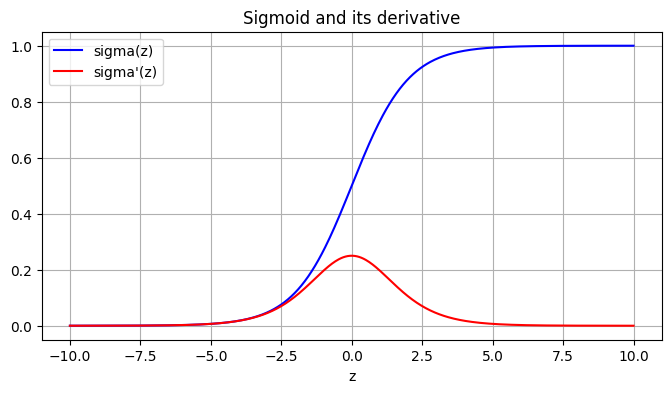

In [ ]:
z = np.linspace(-10, 10, 500)

# TODO: compute sigma and sigma_prime
sigma       = 1 / (1 + np.exp(-z))
sigma_prime = sigma * (1 - sigma)

plt.figure(figsize=(8, 4))
# TODO: plot both curves
plt.plot(z, sigma, label='sigma(z)', color='blue')
plt.plot(z, sigma_prime, label="sigma'(z)", color='red')
plt.xlabel('z')
plt.legend()
plt.title('Sigmoid and its derivative')
plt.grid(True)
plt.show()

### Q4c - Is sigma(100z) basically a perceptron?

A classmate claims: 'a sigmoid neuron with weights multiplied by 100 is basically the same as a perceptron.'

Plot sigma(100z) vs sigma(z) vs the step function. Is the claim correct? Under what condition does it break down?

> **Your answer:**\
> Yes. We can see that sigma(100z) is really close in nature to the heaviside function. The heaviside function is the activation function for a perceptron. Hence sigma(100z) models a perceptron.  
> This breaks down when **z=0** where the function always outputs **0.5**.

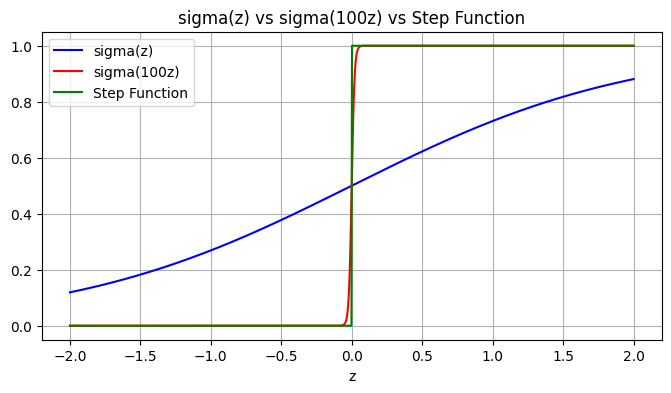

In [ ]:
z = np.linspace(-2, 2, 1000)

# TODO: compute sigma(z), sigma(100*z), step function
sigma       = 1 / (1 + np.exp(-z))
sigma_100z  = 1 / (1 + np.exp(-100*z))
step_function = np.heaviside(z, 0)

plt.figure(figsize=(8, 4))
# TODO: plot all three
plt.plot(z, sigma, label='sigma(z)', color='blue')
plt.plot(z, sigma_100z, label='sigma(100z)', color='red')
plt.plot(z, step_function, label='Step Function', color='green')
plt.title('sigma(z) vs sigma(100z) vs Step Function')
plt.xlabel('z')
plt.legend()
plt.grid(True)
plt.show()

---
## Q5 - Gradient Descent on a Toy Regression Problem

A single-layer network (one input, one output, no activation) must learn y = 3x + 1.

In [ ]:
x_train = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
y_train = np.array([1.0, 4.0, 7.0, 10.0, 13.0])

### Q5a - Analytical Gradients + Full-Batch GD

Derive dC/dw and dC/db analytically (show algebra). Implement full-batch GD with eta = 0.01 for 200 epochs. Plot the loss curve. Do w and b converge to 3 and 1?

**Derivation (show algebra):**

> **Your answer:**\
> $$y_p = wx + b$$  
> $$Cost = \frac{1}{n}\sum_{i=1}^{n}(y_p-y_t)^2 = \frac{1}{n}\sum_{i=1}^{n}(wx_i + b - y_{t_i})^2$$  
> $$\frac{dC}{dw} = \frac{2}{n}\sum_{i=1}^{n}(wx_i + b - y_{t_i})(x_i)$$  
> $$\frac{dC}{db} = \frac{2}{n} \sum_{i=1}^{n} (wx_i + b + y_{t_i})$$  
> Yes, **w and b** converge to **3 and 1** respectively.

Final w = 2.9951, b = 1.0141


/tmp/ipykernel_2035/1926545461.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


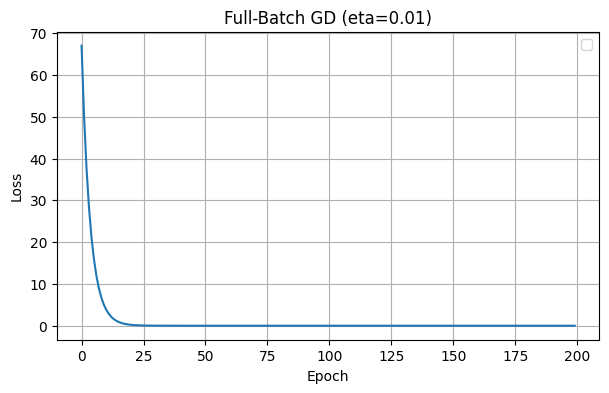

In [ ]:
w, b = 0.0, 0.0
eta = 0.01
losses = []

for epoch in range(200):
    # TODO: predictions, loss, gradients, update
    y_pred = w * x_train + b
    loss = np.mean((y_pred - y_train)**2)
    dw = np.mean(2 * (y_pred - y_train) * x_train)
    db = np.mean(2 * (y_pred - y_train))
    w = w - eta * dw
    b = b - eta * db
    losses.append(loss)

print(f'Final w = {w:.4f}, b = {b:.4f}')
plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Full-Batch GD (eta=0.01)')
plt.legend()
plt.plot()
plt.grid(True)
plt.show()

### Q5b - SGD with Mini-Batch Size = 1

Implement SGD with batch size 1. Train 200 epochs with eta = 0.01. Plot the loss curve. How does it differ from full-batch? Explain in terms of gradient quality and noise.

> **Your answer:**\
> The cost function reaches the minimum in a chaotic manner while using **SGD** (Stochastic Gradient Descent) instead of smoothly like for **GD**(Gradient Descent). This happens because we are taking one traning example at a time instead of generating changes using a group of training data.

Final w = 0.0000, b = 0.0000


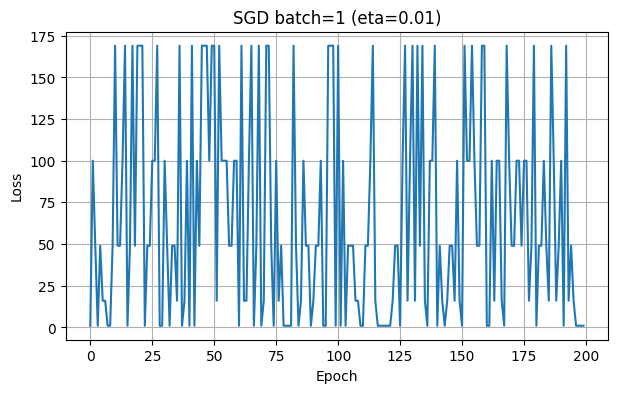

In [ ]:
w, b = 0.0, 0.0
eta = 0.01
losses_sgd = []

for epoch in range(200):
    # TODO: pick random example, compute gradient, update
    idx = np.random.randint(len(x_train))
    x_batch = x_train[idx:idx+1]
    y_batch = y_train[idx:idx+1]
    y_pred = w * x_batch + b
    loss = np.mean((y_pred - y_batch)**2)
    dw = np.mean(2 * (y_pred - y_batch) * x_batch)
    db = np.mean(2 * (y_pred - y_batch))
    losses_sgd.append(loss)

print(f'Final w = {w:.4f}, b = {b:.4f}')
plt.figure(figsize=(7, 4))
plt.plot(losses_sgd)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('SGD batch=1 (eta=0.01)')
plt.grid(True)
plt.show()

### Q5c - Divergence with eta = 0.5

Set eta = 0.5 with full-batch GD. Show the loss curve and explain using the gradient formulas from Q5a why it diverges.

> **Your answer:**  
> Near the minima, the huge step taken due to the bigger learning rate will cause us to land on the other side of the cost function, higher up than we were in the first place (causing a higher loss). Repeated over-stepping causes us to bounce around on the plane of the cost function and we never reach the minima. The high learning rate is the reason the loss diverges.


/tmp/ipykernel_2035/2169597619.py:8: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_pred - y_train)**2)


Diverged at epoch 203


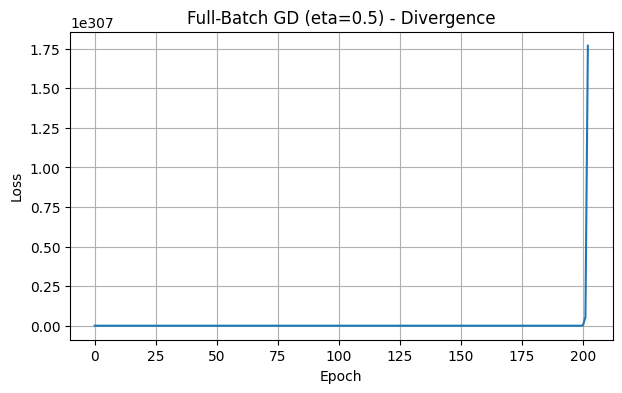

In [ ]:
w, b = 0.0, 0.0
eta = 0.5
losses_div = []

for epoch in range(250):
    # TODO: full-batch GD with eta=0.5
    y_pred = w * x_train + b
    loss = np.mean((y_pred - y_train)**2)
    dw = np.mean(2 * (y_pred - y_train) * x_train)
    db = np.mean(2 * (y_pred - y_train))
    w = w - eta * dw
    b = b - eta * db
    losses_div.append(loss)
    if loss is not None and not np.isfinite(loss):
        print(f'Diverged at epoch {epoch}')
        break

plt.figure(figsize=(7, 4))
plt.plot(losses_div)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Full-Batch GD (eta=0.5) - Divergence')
plt.grid(True)
plt.show()

---
## Q6 - One-Hot to 4-Bit Binary Encoding Layer

A network classifies digits 0-9 with a 10-neuron one-hot output. Design a final **4-neuron layer** that converts this into a **4-bit binary** encoding (e.g. digit 5 outputs 0101). Specify the weight matrix and bias vector.

**Design and Reasoning:**

> **Your answer:**\
> The reasoning is simple. We need to create a **(4x10) weight matrix** that when multiplied with a **(10x1) input vector** gives a **(4x1) output vector** made up of 1s and 0s representing the binary number.  
>
> Since the output has only 1s and 0s, it can be treated as a final layer of perceptrons that have 10 weights each and one bias.    
>\
> \begin{bmatrix}
0&0&0&0&0&0&0&0&1&1\\
0&0&0&0&1&1&1&1&0&0\\
0&0&1&1&0&0&1&1&0&0\\
0&1&0&1&0&1&0&1&0&1\\
\end{bmatrix}  
> This (4x10) matrix is made by putting a one for a neuron's weight only when a number in its binary form has a one in a particular place. This when multiplied by the input vector directly lights up the perceptrons corresponding to the binary form of the decimal number held by the input neuron that is lit up. Hence no bias is needed and the bias vector is simply [0,0,0,0].

In [ ]:
# TODO: define W (4x10) and b_enc (4,)
W  = np.array([
    [0,0,0,0,0,0,0,0,1,1],
    [0,0,0,0,1,1,1,1,0,0],
    [0,0,1,1,0,0,1,1,0,0],
    [0,1,0,1,0,1,0,1,0,1]
    ])  # shape (4, 10)
b_enc = np.zeros(4)  # shape (4,)

def threshold(x):
    return (x >= 0.5).astype(int)

print('Digit | Output | Expected | OK?')
print('-' * 35)
for digit in range(10):
    one_hot = np.zeros(10)
    one_hot[digit] = 1.0
    out = threshold(W @ one_hot + b_enc)
    expected = format(digit, '04b')
    ok = 'OK' if ''.join(map(str, out)) == expected else 'FAIL'
    print(f'  {digit}   |  {out}  |  {expected}  | {ok}')

Digit | Output | Expected | OK?
-----------------------------------
  0   |  [0 0 0 0]  |  0000  | OK
  1   |  [0 0 0 1]  |  0001  | OK
  2   |  [0 0 1 0]  |  0010  | OK
  3   |  [0 0 1 1]  |  0011  | OK
  4   |  [0 1 0 0]  |  0100  | OK
  5   |  [0 1 0 1]  |  0101  | OK
  6   |  [0 1 1 0]  |  0110  | OK
  7   |  [0 1 1 1]  |  0111  | OK
  8   |  [1 0 0 0]  |  1000  | OK
  9   |  [1 0 0 1]  |  1001  | OK


---
## Q7 - Geometric Interpretation of 1D Gradient Descent

Consider C(v) as a function of a single scalar v.

1. Give a precise **geometric interpretation** of the update rule v = v - alpha * dC/dv.
2. How do the slope and the learning rate alpha physically dictate movement along the curve?

> **Your answer:**  
> 1. **dC/dv** gives the direction of steepest increase of the function **C(v)**. When we write **⍺ x dC/dv** we are actually calculating a small step in the direction of fastest increase of the value of the function. But we want to decrease the cost function to go towards a minimum.  
> Hence we write **-⍺ x dC/dv** which is small step in the **direction of fastest decrease**. When added to the current value of v we actually go to a value of v where C(v) is slightly smaller -->  
>  
>$$v_{new} = v - \alpha\cdot\frac{dC}{dv}$$  
>    
> 2. The **learning rate** (⍺) dictates how big of a jump we take along the curve. If the learning rate is **too big**, we can end up reaching a point on the other side of the curve which was higher than the original point. This will lead to a domino effect where we keep shooting higher after every epoch and eventually **C(v) diverges**.  
> When a suitable learning rate is set, the slope decreases as the cost approaches the minima, and the size of the steps are also forced to decrease. This prevents overshooting the minima.

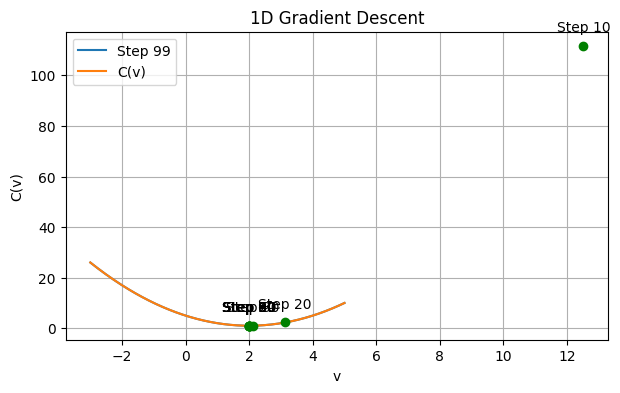

In [ ]:
v_vals = np.linspace(-3, 5, 300)
C_v = (v_vals - 2)**2 + 1

# TODO: run gradient descent steps and annotate on the curve
plt.figure(figsize=(7, 4))
plt.plot(v_vals, C_v, label=f'Step {i}')

v_current = 100
eta = 0.1

for i in range(1, 100):
    grad = 2 * (v_current - 2)
    v_current = v_current - eta * grad
    current_cost = (v_current - 2)**2 + 1
    if i % 10 == 0:
        plt.scatter(v_current, current_cost, color='green', zorder=5)
        plt.annotate(f'Step {i}', (v_current, current_cost),
                     textcoords="offset points", xytext=(0,10), ha='center')
plt.plot(v_vals, C_v, label='C(v)')
plt.xlabel('v')
plt.ylabel('C(v)')
plt.title('1D Gradient Descent')
plt.legend()
plt.grid(True)
plt.show()

---
## Q8 - Zero Hidden Layers: What Model Are You Really Training?

Suppose you remove all hidden layers, connecting 784 inputs directly to 10 outputs, trained with SGD.

1. What **mathematical model** have you effectively created?
2. Why is classification accuracy **fundamentally capped**?
3. What does this imply about the **necessity of hidden layers**?

> **Your answer:**  
> 1. If hidden layers are removed, the network turns into a Linear Classifier.
> 2. The accuracy will be capped since the network does not have freedom to create its own boundries to classify the test data. It does not learn anymore. It will only be able to draw linear boundries and will fail when it comes to variations in the way the number is drawn.
> 3. Hidden layers act as feature identifiers (not directly). The network will then be able to distinguish and pick up certain pattterns about how each number looks and apply that while identifying varied version of numbers that are drawn by hand.